# Infant Rest/Movie dataset results

> **Reproducibility note (read before running):** this notebook is one of a set of
> `0*_*.ipynb` notebooks split out of the original `compiled_results_analysis.ipynb`
> for the publication reproducibility bundle, meant to be run with the repo root (`task_dim/`) as
> the working directory. Each notebook is self-contained (re-loads its own
> inputs rather than relying on variables from other notebooks). A global `SEED = 4` is set at
> the top of the setup cell so every resampling/permutation step below is deterministic.
>
> **Inputs used here are pre-computed.** Where a cell loads a CSV/NIfTI file, a comment states
> which upstream script produced it. A few inputs this notebook depends on
> (`compiled/info/combined_participant_info.csv`, `compiled/results/*_compiled_results.csv`,
> `compiled/results/combined_corrs.csv`, `compiled/results/combined_corr_analyses.csv`) currently
> have **no generating script in this repo** — see `REPRODUCIBILITY.md` at the repo root.

In [2]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import nibabel as nib
from scipy.stats import ttest_ind 
from nilearn import image
from nilearn.maskers import NiftiMasker
from matplotlib.colors import ListedColormap
from matplotlib import rcParams
import plotting_helpers as helper          # surface plots, colormaps, dataset colors
import stats_helpers as stats_helpers      # permutation tests, (parcelwise/LME) regression, FDR correction

rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype'] = 42

PLOT_DIR = 'compiled/plots'
os.makedirs(PLOT_DIR, exist_ok=True)
ISC_CMAP = 'OrRd'
ID_CMAP = helper.custom_blues_cmap()
dataset_colors = helper.dataset_colors('all')

from plotting_helpers import (
    load_atlas, get_region_order,   # Schaefer-400 atlas + region label order
)

# Global seed: makes every unseeded resample/permutation call below reproducible.
SEED = 4
np.random.seed(SEED)

## Load average results (aeronaut, sleep)

In [3]:
# INPUT: infant_restmovie/results/{task}_{measure}_all_subjects_results.nii.gz
#   Stacked per-subject volumes. Produced by searchlight_IDE_methods.py (IDE) /
#   searchlight_isc.py (ISC), then stacked by aggregate_results_volumes.py.
# INPUT: infant_restmovie/masks/InfantRestMovie_intersect_mask_{task}.nii.gz
#   Group intersection mask; produced by create_intersect_mask_file_lists.py +
#   infant_restmovie_config.py / infant_restmovie_utils.py.
atlas_img, atlas_labels = load_atlas()
results_dir_inf = 'infant_restmovie/results'
infant_tasks = ['aeronaut', 'sleep']
measures_inf = {'ISC': 'ISC', 'TPHATE_DiffOp_IDE': 'IDE'}

avg_results_inf = {}
all_results_inf = {}
avg_imgs_inf = {}
for task in infant_tasks:
    avg_results_inf[task] = {}
    all_results_inf[task] = {}
    avg_imgs_inf[task] = {}
    mask_file = f'infant_restmovie/masks/InfantRestMovie_intersect_mask_{task}.nii.gz'
    masker_inf = NiftiMasker(mask_img=mask_file)
    for measure in measures_inf.keys():
        fn = f'{results_dir_inf}/{task}_{measure}_all_subjects_results.nii.gz'
        if os.path.exists(fn):
            img = nib.load(fn)
            masked = masker_inf.fit_transform(img)
            all_results_inf[task][measure] = masked
            mean_data = np.nanmean(img.get_fdata(), axis=3)
            avg_imgs_inf[task][measure] = nib.Nifti1Image(mean_data, img.affine, img.header)
            avg_results_inf[task][measure] = masked
            print(f"Loaded infant {task} {measure}: {masked.shape}, mean={np.nanmean(masked):.3f}, "
                  f"std={np.mean(np.nanstd(masked, axis=1)):.3f}")
        else:
            print(f"Warning: {fn} not found")

[get_dataset_dir] Dataset found in /Users/elb/nilearn_data/schaefer_2018
Loaded infant aeronaut ISC: (26, 61078), mean=0.047, std=0.127
Loaded infant aeronaut TPHATE_DiffOp_IDE: (26, 61078), mean=9.307, std=1.675
Loaded infant sleep ISC: (20, 67032), mean=0.000, std=0.000
Loaded infant sleep TPHATE_DiffOp_IDE: (20, 67032), mean=13.401, std=2.229


/var/folders/1f/s3_5gwyj4j3c18swys7lqz4w0000gn/T/ipykernel_61258/3746241635.py:27: RuntimeWarning: Mean of empty slice
  mean_data = np.nanmean(img.get_fdata(), axis=3)


## Surface grid (aeronaut ISC, aeronaut IDE, sleep IDE)

In [4]:
nifti_imgs_inf = [
    avg_imgs_inf['aeronaut']['ISC'],
    avg_imgs_inf['aeronaut']['TPHATE_DiffOp_IDE'],
    avg_imgs_inf['sleep']['TPHATE_DiffOp_IDE'],
]
titles_inf = ['Aeronaut ISC', 'Aeronaut IDE', 'Sleep IDE']
cbar_ranges_inf = [(0, 0.4), (1, 18), (1, 25)]
cmaps_inf = [ISC_CMAP, ID_CMAP, ID_CMAP]

for idx, (img, title, cmap, cbar_range) in enumerate(zip(nifti_imgs_inf, titles_inf, cmaps_inf, cbar_ranges_inf)):
    fn = title.lower().replace(' ', '_')
    temp_fn = f'compiled/plots/infant_restmovie_{fn}_surface.png'
    helper.generate_surface_plot(
        data_fn=img, image_fn=temp_fn, atlas='searchlight', cmap=cmap,
        cbar_range=cbar_range, surf_type='fslr', target_density='32k',
        include_cbar=True, title=title, method='linear', threshold=None, mask_medial_wall=True
    )

Generated surface plot: compiled/plots/infant_restmovie_aeronaut_isc_surface.png
Generated surface plot: compiled/plots/infant_restmovie_aeronaut_ide_surface.png
Generated surface plot: compiled/plots/infant_restmovie_sleep_ide_surface.png


## TFCE-thresholded aeronaut-sleep difference map + top-ISC overlay

In [5]:
# INPUT: infant_restmovie/results/sleep_aeronaut_two_samp_ttest_output_tfce_corrp_tstat1.nii.gz
#   TFCE-corrected two-sample t-test map (FSL randomise-style output), produced by the
#   HPC difference-map pipeline (searchlight_IDE_methods.py output + FSL TFCE step).
# INPUT: infant_restmovie/results/aeronaut_sleep_TPHATE_DiffOp_IDE_SL_difference_maps_avg_unthresholded.nii.gz
#   Produced by aggregate_results_volumes.py.
d1_inf = nib.load('infant_restmovie/results/sleep_aeronaut_two_samp_ttest_output_tfce_corrp_tstat1.nii.gz')
mask_inf_diff = image.math_img('np.where(X >= 0.95, 1, 0)', X=d1_inf)
mean_img_inf = nib.load('infant_restmovie/results/aeronaut_sleep_TPHATE_DiffOp_IDE_SL_difference_maps_avg_unthresholded.nii.gz')
masked_mean_img_inf = image.math_img('X * Y', X=mean_img_inf, Y=mask_inf_diff)

helper.generate_surface_plot(
    data_fn=masked_mean_img_inf, image_fn=f'{PLOT_DIR}/infant_aeronaut_sleep_diff.pdf',
    atlas='searchlight', surf_type='fslr', target_density='32k', method='linear',
    cmap=helper.diverging_colormap_bp(), cbar_range=(-11, 11),
    include_cbar=True, title='Aeronaut - Sleep IDE (TFCE thresholded)', mask_medial_wall=True
)

/Users/elb/miniforge3/envs/dim_env/lib/python3.9/site-packages/nilearn/image/image.py:1160: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  return new_img_like(niimg, result, niimg.affine)


Generated surface plot: compiled/plots/infant_aeronaut_sleep_diff.pdf


('compiled/plots/infant_aeronaut_sleep_diff.pdf',
 <nibabel.nifti1.Nifti1Image at 0x107a45fd0>)

In [6]:
# Infant: composite plot -- diff map + top ISC overlay
isc_img_inf = avg_imgs_inf['aeronaut']['ISC']
diff_img_inf = masked_mean_img_inf

isc_data_inf = isc_img_inf.get_fdata()
isc_valid_inf = isc_data_inf[~np.isnan(isc_data_inf)]
threshold_inf = 95
isc_thr_inf = np.nanpercentile(isc_valid_inf, threshold_inf)
top_mask_inf = (isc_data_inf >= isc_thr_inf) & ~np.isnan(isc_data_inf)

top_mask_vol_inf = np.full(diff_img_inf.shape, np.nan, dtype=float)
top_mask_vol_inf[top_mask_inf] = 1.0
top_mask_img_inf = nib.Nifti1Image(top_mask_vol_inf, affine=diff_img_inf.affine, header=diff_img_inf.header)

helper.generate_surface_plot(
    data_fn=[diff_img_inf, top_mask_img_inf],
    image_fn=f'{PLOT_DIR}/infant_aeronaut_sleep_diff_top_isc_overlay.pdf',
    atlas='searchlight', cmap=helper.diverging_colormap_bp(), cbar_range=(-11, 11),
    surf_type='fslr', target_density='32k', include_cbar=True,
    title='Aeronaut \u2212 Sleep IDE (thresholded) + Top ISC voxels',
    method='linear', threshold=None, alpha=0.5, mask_medial_wall=True,
    layers_kwargs=[
        dict(cmap=helper.diverging_colormap_bp(), cbar_range=(-11, 11), alpha=1,
             label='\u0394IDE (Aeronaut \u2212 Sleep)', cbar=True),
        dict(cmap=ListedColormap([(1, 1, 0.6, 1.0)]), cbar_range=(0, 1), alpha=0.8,
             label=f'Top {100 - threshold_inf}% ISC mask', cbar=True),
    ],
)

Generated multi-layer surface plot: compiled/plots/infant_aeronaut_sleep_diff_top_isc_overlay.pdf


('compiled/plots/infant_aeronaut_sleep_diff_top_isc_overlay.pdf',
  <nibabel.nifti1.Nifti1Image at 0x107488940>])

## ISC-IDE correlation (per subject, aeronaut)

In [7]:
# INPUT: compiled/results/combined_corr_analyses.csv -- per-subject ISC-IDE permutation
#   correlation z-scores (stats_helpers.permute_pattern). See REPRODUCIBILITY.md for the
#   note on this file's generating step.
df_corr_inf = pd.read_csv('compiled/results/combined_corr_analyses.csv')
df_corr_inf = df_corr_inf[df_corr_inf['dataset'] == 'infant_restmovie']
print(f"Infant ISC-IDE correlation computed for {len(df_corr_inf)} subjects")

Infant ISC-IDE correlation computed for 26 subjects


## Mean IDE barplot by task (aeronaut, mickey, sleep)

Loaded infant aeronaut: 26 subjects
Loaded infant sleep: 20 subjects


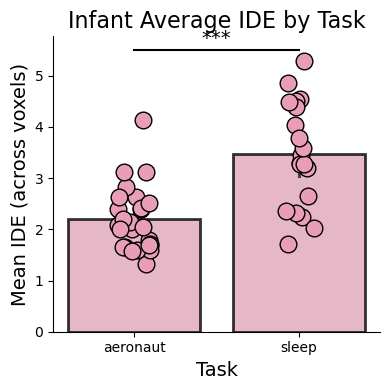

In [9]:
ide_subject_avgs_inf = []
for task in ['aeronaut', 'sleep']:
    ide_fn = f'{results_dir_inf}/{task}_TPHATE_DiffOp_IDE_all_subjects_results.nii.gz'
    if os.path.exists(ide_fn):
        ide_img = nib.load(ide_fn)
        ide_data = ide_img.get_fdata()
        n_subjects = ide_data.shape[3]
        for subj_idx in range(n_subjects):
            mean_ide = np.nanmean(ide_data[:, :, :, subj_idx])
            ide_subject_avgs_inf.append({'task': task, 'subject_id': subj_idx, 'mean_IDE': mean_ide})
        print(f"Loaded infant {task}: {n_subjects} subjects")
    else:
        print(f"Warning: {ide_fn} not found")

ide_df_inf = pd.DataFrame(ide_subject_avgs_inf)
tasks_inf = ['aeronaut', 'sleep']
color = helper.dataset_colors('infant_restmovie')
plt.figure(figsize=(4, 4))
sns.barplot(data=ide_df_inf, x='task', y='mean_IDE', color=color,
            edgecolor='k', linewidth=2, alpha=0.8)
sns.stripplot(data=ide_df_inf, x='task', y='mean_IDE', color=color,
              size=12, alpha=1, jitter=True, edgecolor='k', linewidth=1)
y_max_inf = ide_df_inf['mean_IDE'].max()
for idx, (t1, t2) in enumerate([('aeronaut', 'sleep')]):
    d1 = ide_df_inf[ide_df_inf['task'] == t1]['mean_IDE'].values
    d2 = ide_df_inf[ide_df_inf['task'] == t2]['mean_IDE'].values
    _, p_val = ttest_ind(d1, d2)
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'n.s.'
    y = y_max_inf + 0.2 + idx * 0.4
    x1, x2 = tasks_inf.index(t1), tasks_inf.index(t2)
    plt.plot([x1, x2], [y, y], lw=1.5, c='k')
    plt.text((x1 + x2) * .5, y + 0.05, sig, ha='center', va='bottom', color='k', fontsize=14)
plt.ylabel('Mean IDE (across voxels)', fontsize=14)
plt.xlabel('Task', fontsize=14)
plt.title('Infant Average IDE by Task', fontsize=16)
sns.despine(); plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/infant_avg_ide_by_task_barplot.pdf', format='pdf', transparent=True)
plt.show()

## Parcelwise regression: IDE ~ ISC + age (aeronaut)

In [ ]:
# INPUT: compiled/results/infant_restmovie_compiled_results.csv
# INPUT: compiled/info/combined_participant_info.csv
# Regression itself: stats_helpers.parcelwise_regression (OLS per-parcel + FDR correction)
results_df_inf = pd.read_csv('compiled/results/infant_restmovie_compiled_results.csv', index_col=0)
results_df_inf_aero = results_df_inf[results_df_inf['task'] == 'aeronaut'].copy().reset_index()
par_df = pd.read_csv('compiled/info/combined_participant_info.csv')
par_df_inf_aero = par_df[(par_df['dataset'] == 'InfantRestMovie') & (par_df['task'] == 'aeronaut')].reset_index(drop=True)
REGION_ORDER_INF = get_region_order()
results_df_inf1 = results_df_inf_aero.pivot_table(
    index=['subject_id', 'region_name', 'task'], columns='measure', values='score').reset_index()
results_df_inf1['age_months'] = [
    par_df_inf_aero[par_df_inf_aero['participant_id'] == s]['age_months'].values[0]
    if len(par_df_inf_aero[par_df_inf_aero['participant_id'] == s]) > 0 else np.nan
    for s in results_df_inf1['subject_id'].values]
results_df_inf1['log_age'] = np.log(results_df_inf1['age_months'] + 1)
results_df_inf1['sex'] = [
    par_df_inf_aero[par_df_inf_aero['participant_id'] == s]['sex'].values[0]
    if len(par_df_inf_aero[par_df_inf_aero['participant_id'] == s]) > 0 else np.nan
    for s in results_df_inf1['subject_id'].values]
results_df_inf1['movie_FD'] = [
    par_df_inf_aero[par_df_inf_aero['participant_id'] == s]['movie_FD'].values[0]
    if len(par_df_inf_aero[par_df_inf_aero['participant_id'] == s]) > 0 else np.nan
    for s in results_df_inf1['subject_id'].values]

formula_inf = "TPHATE_DiffOp_IDE ~ ISC + log_age + sex + movie_FD"
a_inf = stats_helpers.parcelwise_regression(results_df_inf1, "log_age", yname="TPHATE_DiffOp_IDE",
                                             formula=formula_inf, region_order=REGION_ORDER_INF,
                                             alpha=0.05, fdr_method='fdr_bh')
a_inf = a_inf.set_index('region_name').reindex(REGION_ORDER_INF).reset_index()

for var, label in [('log_age', 'log_age'), ('ISC', 'isc')]:
    sig_mask = a_inf[f'sig_{var}_fdr'].values
    print(f"For variable '{var}', number of significant regions after FDR correction: {sig_mask.sum()} out of {len(sig_mask)}")
    coef_masked = a_inf[f'coef_{var}'].values * sig_mask
    cbar_range, this_cmap = helper.determine_colorbar_range(coef_masked, helper.diverging_colormap_gpu(), symmetric=True)
    helper.generate_surface_plot(
        coef_masked,
        image_fn=f'{PLOT_DIR}/infant_log_age_predicts_ide_{label}_coef_surface.pdf',
        atlas='Schaefer', cmap=this_cmap, cbar_range=cbar_range,
        surf_type='fslr', target_density='32k', method='linear',
        include_cbar=True, title=rf'$\beta$_{var} (infant aeronaut IDE)', threshold=None, mask_medial_wall=True
    )

[get_dataset_dir] Dataset found in /Users/elb/nilearn_data/schaefer_2018
Using formula: TPHATE_DiffOp_IDE ~ ISC + log_age + sex + movie_FD
For variable 'log_age', number of significant regions after FDR correction: 0 out of 400
[get_dataset_dir] Dataset found in /Users/elb/nilearn_data/schaefer_2018
Generated surface plot: compiled/plots/infant_log_age_predicts_ide_log_age_coef_surface.pdf
For variable 'ISC', number of significant regions after FDR correction: 0 out of 400
[get_dataset_dir] Dataset found in /Users/elb/nilearn_data/schaefer_2018
Generated surface plot: compiled/plots/infant_log_age_predicts_ide_isc_coef_surface.pdf


: 